# Comparing Machine Learning Algorithms for Brain Stroke Detection

## Problem Defintion

One of the most exciting application of Machine Leanring is the disease detection. There have already been previous research on utilizing data from patients in order to determine whether the person was likely to have a disease or not. 

In this project, we are going to be comparing these 6 machine learning algorithms to see which one can predict brain strokes the best based on accuracy, precision, recall, and F1 score. 

The 6 different algorithms are K-Nearest Neighbors, Logistic Regression, Random Forest, Support Vector Machine, Extreme Gradient Boost, and CatBoost



# Exploratory Data Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load Dataset
df = pd.read_csv('data/full_filled_stroke_data.csv')

In [5]:
# Show first 10 rows of the dataset
print(df.shape)
df.head(10)

(201, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1
5,Male,59.0,0,0,Yes,Private,Rural,211.78,33.484568,formerly smoked,1
6,Female,63.0,0,0,Yes,Private,Urban,90.90,30.042545,formerly smoked,1
7,Female,75.0,0,1,No,Self-employed,Urban,109.78,28.318273,Unknown,1
8,Female,76.0,0,0,No,Private,Urban,89.96,28.397893,Unknown,1
9,Male,78.0,1,0,Yes,Private,Urban,75.32,29.139780,formerly smoked,1


In [6]:
# Null Values
null_values = df.isnull().sum()
print(f"Null Values in the Data:\n{null_values}")
print()

# Summary Statistics
df.describe()

Null Values in the Data:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64



,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,52.049154,0.233831,0.164179,126.724627,29.336870,0.199005
std,22.276181,0.424323,0.371363,59.240322,3.363098,0.400249
min,0.480000,0.000000,0.000000,57.520000,17.899295,0.000000
25%,37.000000,0.000000,0.000000,81.430000,28.397893,0.000000
50%,58.000000,0.000000,0.000000,99.870000,29.948147,0.000000
75%,71.000000,0.000000,0.000000,191.790000,31.378534,0.000000
max,82.000000,1.000000,1.000000,260.850000,35.188605,1.000000


From the results above, there are no missing values, which is very fortunate for us as this is usually not the case when utilizing real-world data

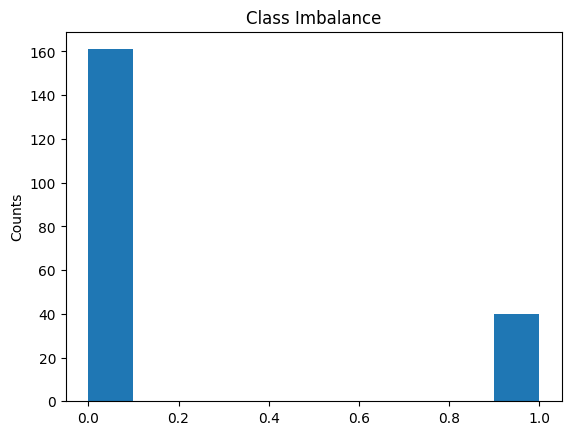

In [22]:
plt.hist(df['stroke'])
plt.ylabel('Counts')
plt.title('Class Imbalance')
plt.savefig("imbalance.png")
plt.show()
plt.close()

From the result above, you can see that we have an imbalance where the minority class is the people with strokes.

We will need to address this either using SMOTE or Cost-Sensitive Learning because in our case, we want to have more examples of the minority class for our models to understand the cases where people have brain strokes.

In [6]:
# Features and their types
X = df.drop(columns='stroke')
y = df['stroke']

numeric_features = X.select_dtypes(include=['int', 'float']).columns.to_list()
category_features = X.select_dtypes(exclude=['int', 'float']).columns.to_list()

print(f'Numerical Features: {numeric_features}')
print()
print(f'Categorical Features: {category_features}')
print()

# The unique values in each categorical feature to determine whether they are nomial or ordinal
for column in category_features:
    unique_values = sorted(X[column].unique())
    print(f"The Unique Values in {column} are: {unique_values}")
    print()

Numerical Features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

Categorical Features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

The Unique Values in gender are: ['Female', 'Male']

The Unique Values in ever_married are: ['No', 'Yes']

The Unique Values in work_type are: ['Govt_job', 'Private', 'Self-employed', 'children']

The Unique Values in Residence_type are: ['Rural', 'Urban']

The Unique Values in smoking_status are: ['Unknown', 'formerly smoked', 'never smoked', 'smokes']



From the results above, the only categorical feature that could be a smoking status. However, The ordinal order of it will be interesting because Unknown means it be anyting in terms of amount of smoking. 

The ordering might be 'never smoked', 'Unknown', 'formerly smoked', and 'smokes'. 

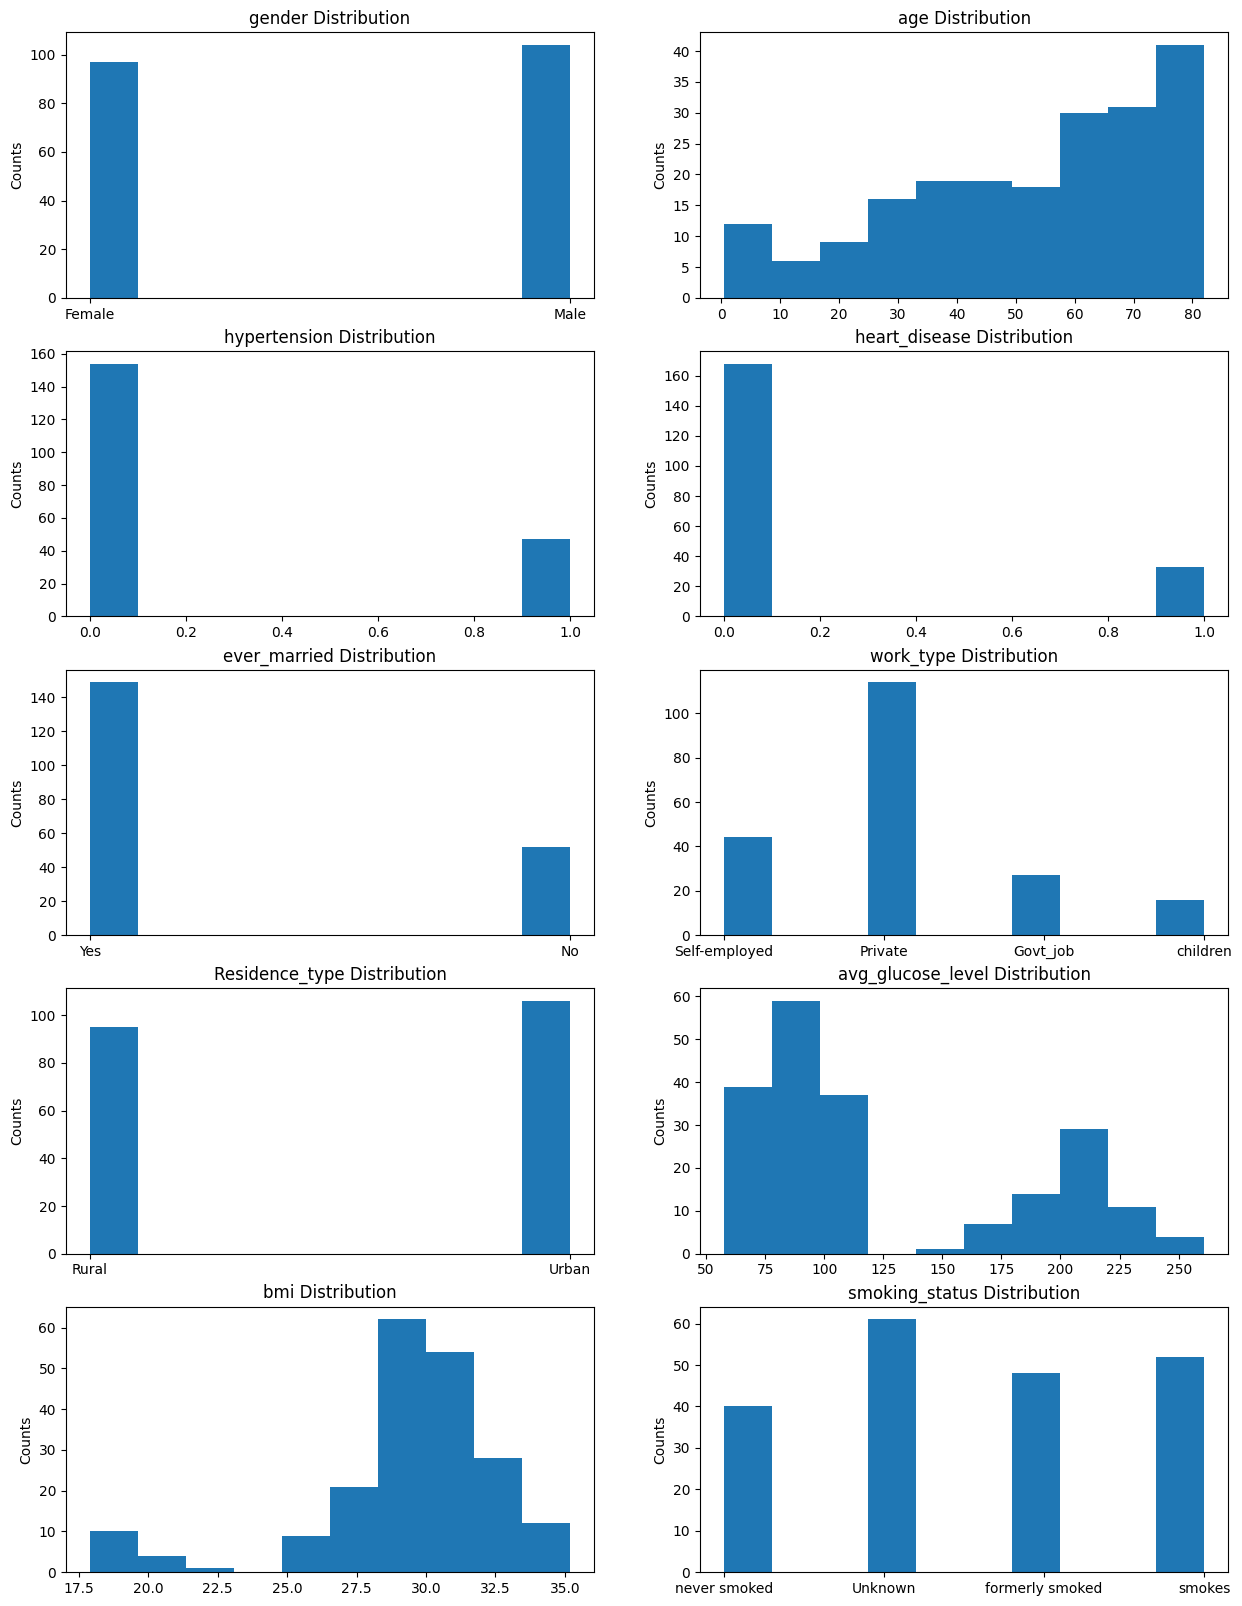

In [7]:
# Distribution of features
fig, axes = plt.subplots(5, 2, figsize=(15,20))

flat_axes = axes.flatten()

for column, ax in zip(X.columns, flat_axes):
    ax.hist(df[column])
    ax.set_ylabel("Counts")
    ax.set_title(f"{column} Distribution")

fig.savefig(fname='features_distributions.png')

From the histograms above, we can see Hypertension, Ever Married, and Heart Disease features have a lot of imbalance, as they skew right.

The average glucose levels and bmi distibutions are very similar but in reverse, where one part looks normally distribution and another part is separate. 

The smoking status and gender distributions is fairly well balanced. 

The Age distributions skew slightly left, which makes sense since the older 
an individual is, the more likely the person will have brain stroke.



age                  0.353495
hypertension        -0.098721
heart_disease        0.014560
avg_glucose_level   -0.040227
bmi                  0.003663
dtype: float64

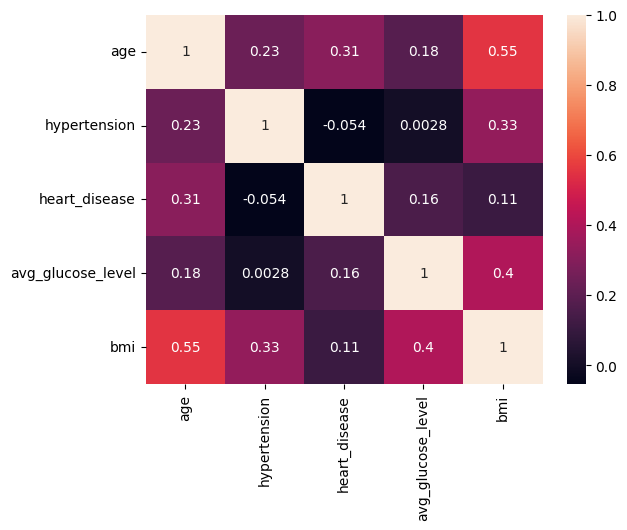

In [8]:
# Correlation Matrix for numerical features with each other
num_features = X.select_dtypes(include=['int', 'float'])
correlation = sns.heatmap(num_features.corr(), annot=True)
figure = correlation.get_figure()
figure.savefig(fname="correlation_heatmap.png")

# How correlated are numerical features to the label
num_features.corrwith(y)

From the data, it looks like age has the highest correlation to having a brain stroke, which makes sense since older people usually suffer strokes just in general. 

From the Heatmap, bmi and age have the biggest correlation, followed by heart disease and age, and hypertension and age.

## Data Preprocessing

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, SVMSMOTE

In [10]:
numerical_features = X[numeric_features]
categorical_features = X[category_features]

# Numerical Pipeline 
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline(steps=[
('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OneHotEncoder(handle_unknown='ignore'))])

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, X.select_dtypes(include=['int', 'float']).columns),
    ('cat', categorical_pipeline, X.select_dtypes(exclude=['int', 'float']).columns)
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# SMOTE
smote_x, smote_y = SVMSMOTE(sampling_strategy=0.5, random_state=42).fit_resample(X_train, y_train)

## Model Training + Evaluation

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

For this project, I will used the hyperparameters found in the paper for all the models outside of catboost. I will utilize gridsearch for catboost for hyperparameter tuning

CatBoost has their own version of grid search cross validation so I will use that for the its hyperparameter tuning

In [13]:
# These values are based on the paper
knn_model = KNeighborsClassifier(n_neighbors=7)
lr_model = LogisticRegression(C=1.0, solver='liblinear')
rf_model = RandomForestClassifier(criterion='entropy', max_depth=9, max_features='log2', n_estimators=88)
svm_model = svm.SVC(C=10, kernel='rbf', gamma=1, probability=True)

xgboost_params = {
    'colsample_bytree': 0.6143,
    'learning_rate': 0.6959,
    'max_depth': 8,
    'min_child_weight': 1,
    'n_estimators': 283,
    'subsample': 0.5813
}

xgboost_model = XGBClassifier(**xgboost_params)
catboost_model_no_tuning = CatBoostClassifier(silent=True)
catboost_model = CatBoostClassifier(silent=True)


### Hyperparameter Tuning at Catboost

We will perform hyperparameter tuning on Catboost utilizing random earch

In [14]:
catboost_params = {
    'iterations': np.arange(1000, step=1), 
    'learning_rate': np.arange(1, step=0.01),
    'depth': np.arange(8, step=1),
    'l2_leaf_reg': np.arange(10, step=1),
}

catboost_model.randomized_search(catboost_params, smote_x, smote_y, cv=10, n_iter=100)



bestTest = 0.578770899
bestIteration = 22

0:	loss: 0.5787709	best: 0.5787709 (0)	total: 65.8ms	remaining: 6.51s

bestTest = 0.5787707284
bestIteration = 19

1:	loss: 0.5787707	best: 0.5787707 (1)	total: 87.7ms	remaining: 4.3s

bestTest = 0.5796964653
bestIteration = 18

2:	loss: 0.5796965	best: 0.5787707 (1)	total: 120ms	remaining: 3.88s

bestTest = 0.5791162764
bestIteration = 3

3:	loss: 0.5791163	best: 0.5787707 (1)	total: 160ms	remaining: 3.83s

bestTest = 0.5788992491
bestIteration = 2

4:	loss: 0.5788992	best: 0.5787707 (1)	total: 193ms	remaining: 3.67s

bestTest = 0.5789151308
bestIteration = 6

5:	loss: 0.5789151	best: 0.5787707 (1)	total: 230ms	remaining: 3.61s

bestTest = 0.5795277044
bestIteration = 29

6:	loss: 0.5795277	best: 0.5787707 (1)	total: 273ms	remaining: 3.62s

bestTest = 0.5791379374
bestIteration = 12

7:	loss: 0.5791379	best: 0.5787707 (1)	total: 325ms	remaining: 3.74s

bestTest = 0.5794380333
bestIteration = 10

8:	loss: 0.5794380	best: 0.5787707 (1)	total: 

{'params': {'depth': 4,
  'learning_rate': 0.61,
  'l2_leaf_reg': 5,
  'iterations': 962},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45

From the code, we can see that these is our best hyperparameters for this model

In [15]:
models = [('KNN', knn_model), ('LR', lr_model),('RF', rf_model), ('SVM', svm_model), ('XGB', xgboost_model), ('CatBoost Default', catboost_model_no_tuning), ('CatBoost Tuning', catboost_model)]

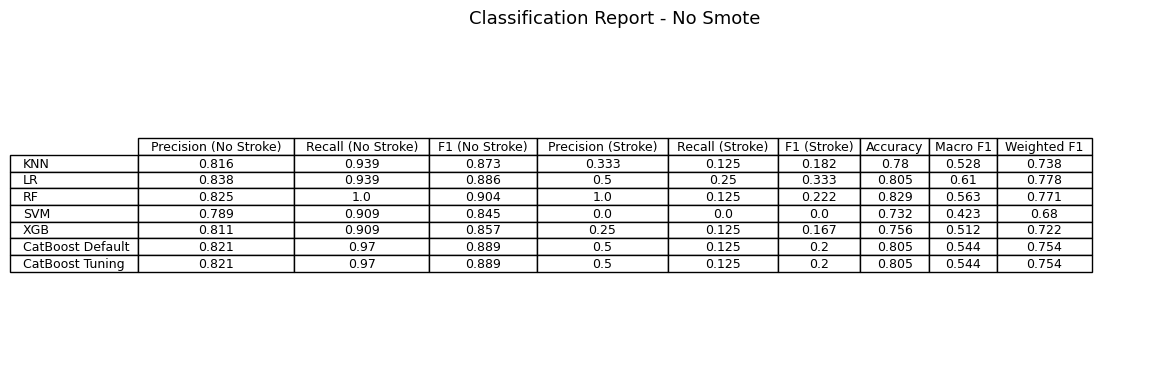

In [16]:
# Training and Evaluation without SMOTE
final_report_no_smote = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    final_report_no_smote.append({
        'Model': name,
        'Precision (No Stroke)': report['0']['precision'],
        'Recall (No Stroke)': report['0']['recall'],
        'F1 (No Stroke)': report['0']['f1-score'],
        'Precision (Stroke)': report['1']['precision'],
        'Recall (Stroke)': report['1']['recall'],
        'F1 (Stroke)': report['1']['f1-score'],
        'Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
    })

results_no_smote = pd.DataFrame(final_report_no_smote).set_index('Model').round(3)
results_no_smote.to_csv("classification_report_no_smote.csv")

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

table = ax.table(
    cellText=results_no_smote.values,
    rowLabels=results_no_smote.index,
    colLabels=results_no_smote.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(results_no_smote.columns))))

ax.set_title('Classification Report - No Smote', fontsize=13, pad=20)
fig.savefig('classification_report_no_smote.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()



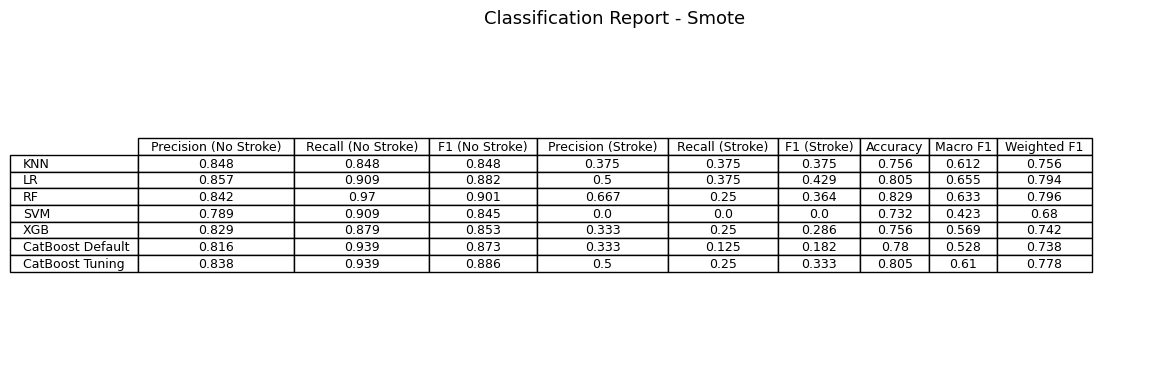

In [17]:
# Training and Evaluation with SMOTE
final_report_with_smote = []
for name, model in models:
    model.fit(smote_x, smote_y)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    final_report_with_smote.append({
        'Model': name,
        'Precision (No Stroke)': report['0']['precision'],
        'Recall (No Stroke)': report['0']['recall'],
        'F1 (No Stroke)': report['0']['f1-score'],
        'Precision (Stroke)': report['1']['precision'],
        'Recall (Stroke)': report['1']['recall'],
        'F1 (Stroke)': report['1']['f1-score'],
        'Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
    })

results_smote = pd.DataFrame(final_report_with_smote).set_index('Model').round(3)
results_smote.to_csv("classification_report_smote.csv")
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

table = ax.table(
    cellText=results_smote.values,
    rowLabels=results_smote.index,
    colLabels=results_smote.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(results_smote.columns))))

ax.set_title('Classification Report - Smote', fontsize=13, pad=20)
fig.savefig('classification_report_smote.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close(fig)



## Feature Importance

In [18]:
from sklearn.inspection import permutation_importance

In [19]:
for name, model in models:
    fig, ax = plt.subplots(figsize=(16, 20))
    importance = None
    if hasattr(model, 'feature_importances_'):
        print(f"Feature Importance: {name}")
        importance = model.feature_importances_
    elif hasattr(model, 'coef_'):
        print(f"Coefficient: {name}")
        importance = np.abs(model.coef_[0])
    else:
        print(f"Permutation Importance: {name}")
        importance = np.abs(permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42).importances_mean)

    one_hot_encoded_features = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(category_features)
    importance_df = pd.DataFrame({
    'Feature': numeric_features + list(one_hot_encoded_features),
    'Importance': importance}).sort_values('Importance', ascending=False)

    ax.bar(importance_df['Feature'], importance_df['Importance'], color='Aqua')
    ax.set_title(f'{name} Feature Importance')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    fig.savefig(f'feature_importance_{name}.png')
    plt.close(fig)

Permutation Importance: KNN
Coefficient: LR
Feature Importance: RF
Permutation Importance: SVM
Feature Importance: XGB
Feature Importance: CatBoost Default
Feature Importance: CatBoost Tuning
